# Pricing US Flood Risk at underwriting

### SMM284 Applied Machine Learning Group 09


## 1. Setup

Formatter: `Black`


In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn import set_config
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import TweedieRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap

# keep the notebook output clean
warnings.filterwarnings("ignore")
# show pipelines as diagrams
set_config(display="diagram")
# group 09 (ﾉ◕ヮ◕)ﾉ*:･ﾟ✧
RANDOM_STATE = 9
plt.rcParams["figure.figsize"] = (9, 4.5)
pd.set_option("display.max_columns", 40)
print("setup done")

setup done


In [105]:
# freeze environment -> requirements.txt
# (install with `pip install -r requirements.txt`)
import subprocess
import sys

# get exact Python executable running this notebook
python_exe = sys.executable

# -> pip freeze using this specific Python executable
result = subprocess.run(
    [python_exe, "-m", "pip", "freeze"], capture_output=True, text=True
)

# write to requirements.txt
with open("requirements.txt", "w") as f:
    f.write(result.stdout)

print("> requirements.txt generated.")

> requirements.txt generated.


## 2. Data acquisition - Federal Emergency Management Agency (FEMA) OpenFEMA (National Flood Insurance Program [NFIP] claims)

_See https://www.fema.gov/openfema-data-page/fima-nfip-redacted-policies-v2 for
additional background information_


In [106]:
# Data acquisition
# Source: FEMA OpenFEMA "FIMA NFIP Redacted Claims" v2
# (~2.72M rows, refreshed ~monthly). The metadata API is used only for the
# dataset descriptor and field schema. The records come from the bulk parquet,
# downloaded once and cached under data/raw/ with a 'provenance sidecar'.
#
# BE note: only learned the term provenance sidecar through this project
#   "a provenance sidecar is a specialized design pattern used to track and 
#   verify the history of software artifacts without burdening the application 
#   code itself."
from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import requests

# --- Endpoints -------------------------------------------------------------
METADATA_BASE = "https://www.fema.gov/api/open/v1"
DATA_API = "https://www.fema.gov/api/open/v2/FimaNfipClaims"
DATASET_NAME = "FimaNfipClaims"
DATASET_VERSION = 2

RAW_DIR = Path("data/raw")
RAW_PARQUET = RAW_DIR / "FimaNfipClaimsV2.parquet"
PROVENANCE = RAW_DIR / "provenance.json"

# --- Column contract (the leakage boundary) --------------------------------
TARGET = "amountPaidOnBuildingClaim"

# Known at underwriting time -> legal features for a pricing model
UNDERWRITING_FEATURES = [
    "ratedFloodZone",
    "elevationDifference",
    "baseFloodElevation",
    "lowestFloorElevation",
    "lowestAdjacentGrade",
    "elevatedBuildingIndicator",
    "basementEnclosureCrawlspaceType",
    "obstructionType",
    "occupancyType",
    "numberOfFloorsInTheInsuredBuilding",
    "buildingDescriptionCode",
    "condominiumCoverageTypeCode",
    "postFIRMConstructionIndicator",
    "originalConstructionDate",
    "primaryResidenceIndicator",
    "rentalPropertyIndicator",
    "totalBuildingInsuranceCoverage",
    "totalContentsInsuranceCoverage",
    "buildingDeductibleCode",
    "crsClassificationCode",
    "elevationCertificateIndicator",
]

# Known only after the flood -> leakage for a pricing model
# can't use as features
# BE note: this dataset contains just flooded properties, but some have a 0
# claim amount
POST_FLOOD_FIELDS = [
    "waterDepth",
    "floodWaterDuration",
    "floodCharacteristicsIndicator",
    "causeOfDamage",
    "floodEvent",
    "eventDesignationNumber",
    "ficoNumber",
    "buildingDamageAmount",
    "contentsDamageAmount",
    "amountPaidOnContentsClaim",
    "netBuildingPaymentAmount",
    "netContentsPaymentAmount",
    "replacementCostBasis",
    "nonPaymentReasonBuilding",
    "nonPaymentReasonContents",
]

# Geography + time for EDA
# includes the zone/state baseline, and grouped CV splits
CONTEXT = [
    "state",
    "countyCode",
    "yearOfLoss",
    "dateOfLoss",
    "latitude",
    "longitude",
]

# Diagnostic fields for the under-insurance rider (not pricing features)
RIDER = ["buildingReplacementCost", "buildingPropertyValue"]

# what to load from parquet
# (target + legal features + context + rider)
LOAD_COLUMNS = [TARGET] + UNDERWRITING_FEATURES + CONTEXT + RIDER


# --- Metadata API ----------------------------------------------------------
def _get_json(path: str, params: dict) -> dict:
    """GET a small OpenFEMA metadata payload as JSON."""
    resp = requests.get(f"{METADATA_BASE}/{path}", params=params, timeout=60)
    resp.raise_for_status()
    return resp.json()


def get_dataset_metadata() -> dict:
    """Dataset descriptor: bulk file URLs, record count, refresh stamp, hash."""
    payload = _get_json("OpenFemaDataSets", {"$filter": f"name eq '{DATASET_NAME}'"})
    ds = payload["OpenFemaDataSets"][0]
    dist = {d["format"]: d["accessURL"] for d in ds["distribution"]}
    return {
        "record_count": ds["recordCount"],
        "parquet_url": dist["parquet"],
        "csv_url": dist["csv"],
        "last_refresh": ds["lastDataSetRefresh"],
        "hash": ds["hash"],
        "version": ds["version"],
    }


def get_field_schema() -> pd.DataFrame:
    """Field dictionary as a DataFrame (name, type, description, key, nullable)."""
    payload = _get_json(
        "OpenFemaDataSetFields",
        {
            "$filter": f"openFemaDataSet eq '{DATASET_NAME}' "
            f"and datasetVersion eq {DATASET_VERSION}"
        },
    )
    fields = pd.DataFrame(payload["OpenFemaDataSetFields"])
    return fields[["name", "type", "description", "primaryKey", "isNullable"]]


# --- Bulk download + load --------------------------------------------------
def download_raw(force: bool = False) -> Path:
    """Download the bulk Parquet once into data/raw/; skip if already cached.

    Writes a provenance.json sidecar (source URL, FEMA hash, expected row
    count, download time) so the run is reproducible and auditable.
    """
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    if RAW_PARQUET.exists() and not force:
        return RAW_PARQUET

    meta = get_dataset_metadata()
    print(f"Downloading bulk parquet (~50-500 MB):\n  {meta['parquet_url']}")
    with requests.get(meta["parquet_url"], stream=True, timeout=600) as r:
        r.raise_for_status()
        with open(RAW_PARQUET, "wb") as fh:
            for chunk in r.iter_content(chunk_size=1 << 20):  # 1 MB chunks
                fh.write(chunk)

    PROVENANCE.write_text(
        json.dumps(
            {
                "parquet_url": meta["parquet_url"],
                "fema_hash": meta["hash"],
                "expected_record_count": meta["record_count"],
                "last_refresh": meta["last_refresh"],
                "downloaded_at": datetime.now(timezone.utc).isoformat(),
            },
            indent=2,
        )
    )
    print(f"Saved -> {RAW_PARQUET}")
    return RAW_PARQUET


def load_raw(
    columns: list[str] | None = LOAD_COLUMNS, validate: bool = True
) -> pd.DataFrame:
    """Load the cached Parquet (default: the project's ~30 columns via pushdown).

    Pass columns=None to load all 73 fields. Row count is checked against the
    recorded provenance as a soft warning (FEMA refreshes monthly, so a drift
    is informative, not an error).
    """
    path = download_raw()
    df = pd.read_parquet(path, columns=columns, engine="pyarrow")

    if validate and PROVENANCE.exists():
        expected = json.loads(PROVENANCE.read_text())["expected_record_count"]
        if len(df) != expected:
            print(
                f"NOTE: loaded {len(df):,} rows; provenance expected "
                f"{expected:,}. FEMA likely refreshed the file — "
                f"re-run download_raw(force=True) to re-pin provenance."
            )
    return df


# --- Small API slice (for quick dev / building the shared fixture) ---------
def fetch_api_sample(n: int = 1000, where: str | None = None) -> pd.DataFrame:
    """Pull up to n rows via the v2 data API (paged in 1,000s).

    Use for fast iteration or to build the committed dev fixture, e.g.
    fetch_api_sample(2000, where="state eq 'TX' and yearOfLoss eq 2017").
    Do NOT use this to assemble the full dataset — use the bulk parquet.
    """
    rows, skip, page = [], 0, min(n, 1000)
    while len(rows) < n:
        params = {"$top": page, "$skip": skip, "$format": "json"}
        if where:
            params["$filter"] = where
        resp = requests.get(DATA_API, params=params, timeout=120)
        resp.raise_for_status()
        batch = resp.json().get(DATASET_NAME, [])
        if not batch:
            break
        rows.extend(batch)
        skip += page
    return pd.DataFrame(rows[:n])

In [107]:
# Sample fixture
#   cut a small, representative parquet slice for fast testing
# Stratified by state x decade, with the known edge cases forced in so every
# cleaning code path is exercised even on the small slice.
# Note: Building it requires the full parquet (downloaded if absent).
SAMPLE_PARQUET = Path("data/sample/nfip_sample.parquet")


def build_sample(target_rows: int = 30_000, seed: int = 284) -> Path:
    """Build the committed sample slice from the full parquet."""
    SAMPLE_PARQUET.parent.mkdir(parents=True, exist_ok=True)
    # all cols, including 'id'
    full = pd.read_parquet(download_raw(), engine="pyarrow")
    print(f"full: {len(full):,} rows x {full.shape[1]} cols")

    # Strata key as a standalone Series
    #   -> never added to full, nothing to drop later
    decade = pd.to_numeric(full["yearOfLoss"], errors="coerce") // 10 * 10
    strata_key = (
        full["state"].astype("string").fillna("NA")
        + "_"
        + decade.astype("string").fillna("NA")
    )

    frac = min(1.0, target_rows / len(full))

    # Proportional sample per stratum, min 1 per group
    # group_keys=False keeps it flat
    sample = (
        full.groupby(strata_key, group_keys=False)
        .apply(lambda g: g.sample(max(1, int(round(len(g) * frac))), random_state=seed))
        .reset_index(drop=True)
    )

    # Guarantee the known edge cases are present (don't rely on luck)
    def force_in(sample, mask, n, label):
        extra = full.loc[mask]
        if len(extra):
            add = extra.sample(min(n, len(extra)), random_state=seed)
            sample = pd.concat([sample, add]).drop_duplicates(subset="id")
            print(f"  +{min(n, len(extra))} {label}")
        return sample

    bld = pd.to_numeric(full["amountPaidOnBuildingClaim"], errors="coerce")
    sample = force_in(sample, bld < 0, 50, "negative payouts")
    sample = force_in(sample, bld == 0, 200, "zero/denied payouts")
    sample = force_in(
        sample,
        pd.to_numeric(full["elevationDifference"], errors="coerce") == 9999,
        200,
        "elev 9999 sentinels",
    )
    sample = force_in(
        sample,
        pd.to_numeric(full["occupancyType"], errors="coerce") >= 11,
        200,
        "Risk Rating 2.0 codes",
    )
    sample = force_in(
        sample,
        pd.to_numeric(full["yearOfLoss"], errors="coerce") < 1996,
        200,
        "pre-1996 records",
    )

    # shuffle
    sample = sample.sample(frac=1, random_state=seed).reset_index(drop=True)
    sample.to_parquet(SAMPLE_PARQUET, engine="pyarrow", compression="zstd")

    mb = SAMPLE_PARQUET.stat().st_size / 1e6
    print(
        f"wrote {SAMPLE_PARQUET}: {len(sample):,} rows x {sample.shape[1]} cols, {mb:.2f} MB"
    )
    if mb > 2.0:
        print("Above ~2 MB — re-run with target_rows=15_000 (zstd already on).")
    return SAMPLE_PARQUET

In [108]:
# --- data selection toggle ---------------------------------------------------
# True  -> ~30k-row representative slice: fast, for testing the pipeline
#          end-to-end before leaving the tuning to run
# False -> full dataset (~2.7M rows): the real run
USE_SAMPLE = True

# BE note: at Bayes library the full download takes ~15.4 seconds

if USE_SAMPLE:
    if not SAMPLE_PARQUET.exists():
        # blank directory: builds the slice 
        # (downloads the full parquet first if it is also missing)
        build_sample()
    DATA_PATH = SAMPLE_PARQUET
else:
    download_raw()  # no-op if already cached
    DATA_PATH = RAW_PARQUET

# same column pushdown for both, so df has an identical shape in either mode
df = pd.read_parquet(DATA_PATH, columns=LOAD_COLUMNS, engine="pyarrow")

mode = "SAMPLE (testing)" if USE_SAMPLE else "FULL"
print(
    f"mode: {mode}   loaded {DATA_PATH}  ->  rows: {len(df):,}   columns: {df.shape[1]}"
)
df.head(3)

mode: SAMPLE (testing)   loaded data/sample/nfip_sample.parquet  ->  rows: 30,660   columns: 30


,amountPaidOnBuildingClaim,ratedFloodZone,elevationDifference,baseFloodElevation,lowestFloorElevation,lowestAdjacentGrade,elevatedBuildingIndicator,basementEnclosureCrawlspaceType,obstructionType,occupancyType,numberOfFloorsInTheInsuredBuilding,buildingDescriptionCode,condominiumCoverageTypeCode,postFIRMConstructionIndicator,originalConstructionDate,primaryResidenceIndicator,rentalPropertyIndicator,totalBuildingInsuranceCoverage,totalContentsInsuranceCoverage,buildingDeductibleCode,crsClassificationCode,elevationCertificateIndicator,state,countyCode,yearOfLoss,dateOfLoss,latitude,longitude,buildingReplacementCost,buildingPropertyValue
0,None,A05,None,None,None,None,True,2.0,60.0,1.0,2.0,NaN,N,False,1952-07-01,True,False,134600.0,0.0,2,NaN,1,VA,51735,1999,1999-12-16,37.1,-76.4,82236.0,65788.0
1,3202.76,AE,None,None,None,None,False,1.0,NaN,1.0,2.0,NaN,N,False,1955-01-01,True,False,153700.0,10400.0,2,NaN,NaN,IL,17031,2008,2008-09-12,41.9,-87.9,98672.0,46376.0
2,360.07,A,None,None,None,None,False,NaN,10.0,4.0,1.0,NaN,N,False,1492-10-12,False,False,100000.0,100000.0,0,NaN,1,PA,42071,1979,1979-08-30,40.0,-76.0,0.0,319400.0


In [109]:
schema = get_field_schema()  # name / type / description / key / nullable
schema.head()

,name,type,description,primaryKey,isNullable
0,asOfDate,datetime,The effective date of the data in the file. In...,False,True
1,amountPaidOnBuildingClaim,"decimal(12,2)",Dollar amount paid on the building claim. In s...,False,True
2,amountPaidOnContentsClaim,"decimal(12,2)",Dollar amount paid on the contents claim. In s...,False,True
3,amountPaidOnIncreasedCostOfComplianceClaim,"decimal(12,2)",ICC coverage is one of several flood insurance...,False,True
4,netBuildingPaymentAmount,"decimal(12,2)",Net building payment amount made to insured in...,False,True


## 3. Initial look


In [110]:
display(df.dtypes)
# sparsest columns first
df.isna().mean().sort_values(ascending=False).head(20)

amountPaidOnBuildingClaim              object
ratedFloodZone                            str
elevationDifference                    object
baseFloodElevation                     object
lowestFloorElevation                   object
lowestAdjacentGrade                    object
elevatedBuildingIndicator                bool
basementEnclosureCrawlspaceType       float64
obstructionType                       float64
occupancyType                         float64
numberOfFloorsInTheInsuredBuilding    float64
buildingDescriptionCode               float64
condominiumCoverageTypeCode               str
postFIRMConstructionIndicator            bool
originalConstructionDate               object
primaryResidenceIndicator                bool
rentalPropertyIndicator                  bool
totalBuildingInsuranceCoverage        float64
totalContentsInsuranceCoverage        float64
buildingDeductibleCode                    str
crsClassificationCode                 float64
elevationCertificateIndicator     

crsClassificationCode                 0.950294
lowestAdjacentGrade                   0.810176
elevationCertificateIndicator         0.776419
lowestFloorElevation                  0.765068
baseFloodElevation                    0.756556
elevationDifference                   0.730724
basementEnclosureCrawlspaceType       0.696347
buildingDescriptionCode               0.637280
obstructionType                       0.443901
buildingReplacementCost               0.221787
buildingPropertyValue                 0.221755
amountPaidOnBuildingClaim             0.206784
buildingDeductibleCode                0.102022
ratedFloodZone                        0.051957
countyCode                            0.022798
longitude                             0.014938
latitude                              0.014938
condominiumCoverageTypeCode           0.014547
numberOfFloorsInTheInsuredBuilding    0.006915
originalConstructionDate              0.000881
dtype: float64

count     24320
unique    20489
top        0.00
freq       1885
Name: amountPaidOnBuildingClaim, dtype: object
zero payouts: 6.1%
negative payouts: 50


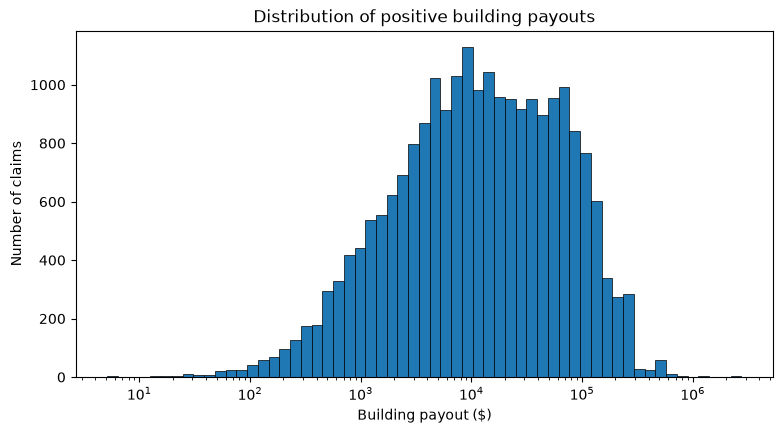

In [111]:
print(df[TARGET].describe())
# denied / no building payment
print(f"zero payouts: {(df[TARGET] == 0).mean():.1%}")
# re-issued cheques
print(f"negative payouts: {(df[TARGET] < 0).sum():,}")

# positive payouts
pos = df[df[TARGET] > 0][TARGET].astype(float)
# calc bins and counts using numpy (faster)
bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), 60)
counts, edges = np.histogram(pos, bins=bins)
# plt.stairs(counts, edges, fill=True)
plt.bar(
    x=edges[:-1],
    height=counts,
    width=np.diff(edges),
    align="edge",
    edgecolor="black",
    linewidth=0.5,
)
plt.xscale("log")
plt.xlabel("Building payout ($)")
plt.ylabel("Number of claims")
plt.title("Distribution of positive building payouts")
plt.show()

In [112]:
# check for missing values where "9999" was entered to show it was missing
for col in ["elevationDifference", "baseFloodElevation"]:
    is_sentinel = df[col] == 9999
    print(f"{col} == 9999 sentinel: {is_sentinel.sum():,} ({is_sentinel.mean():.1%})")
# BE note: 0 for both -> so nothing to worry about

print("\nOccupancy Type:")
print(df["occupancyType"].value_counts().head(12).apply(lambda x: f"{x:,}"))
# 1-digit legacy vs 2-digit Risk Rating 2.0
print(df["ratedFloodZone"].value_counts().head(12).apply(lambda x: f"{x:,}"))

elevationDifference == 9999 sentinel: 0 (0.0%)
baseFloodElevation == 9999 sentinel: 0 (0.0%)

Occupancy Type:
occupancyType
1.0     20,080
11.0     4,770
4.0      1,906
2.0      1,468
3.0        863
18.0       434
15.0       323
6.0        285
12.0       208
16.0       121
14.0       109
13.0        82
Name: count, dtype: str
ratedFloodZone
AE     10,554
X       4,643
A       2,288
C       1,852
B       1,255
A04       608
A01       582
VE        560
A05       530
A06       526
A08       497
A07       465
Name: count, dtype: str


In [113]:
print("Missing (NaN) values in Underwriting Features:")

# Calculate the number of missing values per column
missing_counts = df[UNDERWRITING_FEATURES].isna().sum()

# Filter for columns that actually have missing data, and sort highest to lowest
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

# Print the formatted results
for col, count in missing_counts.items():
    pct = count / len(df)
    print(f"{col}: \t{count:,} \t({pct:.1%})")

Missing (NaN) values in Underwriting Features:
crsClassificationCode: 	29,136 	(95.0%)
lowestAdjacentGrade: 	24,840 	(81.0%)
elevationCertificateIndicator: 	23,805 	(77.6%)
lowestFloorElevation: 	23,457 	(76.5%)
baseFloodElevation: 	23,196 	(75.7%)
elevationDifference: 	22,404 	(73.1%)
basementEnclosureCrawlspaceType: 	21,350 	(69.6%)
buildingDescriptionCode: 	19,539 	(63.7%)
obstructionType: 	13,610 	(44.4%)
buildingDeductibleCode: 	3,128 	(10.2%)
ratedFloodZone: 	1,593 	(5.2%)
condominiumCoverageTypeCode: 	446 	(1.5%)
numberOfFloorsInTheInsuredBuilding: 	212 	(0.7%)
originalConstructionDate: 	27 	(0.1%)
occupancyType: 	8 	(0.0%)


## 4. Cleaning and claim selection


In [114]:
# text -> numeric (including payout target)
num_coerce = [
    "amountPaidOnBuildingClaim",
    "totalBuildingInsuranceCoverage",
    "totalContentsInsuranceCoverage",
    "elevationDifference",
    "baseFloodElevation",
    "lowestFloorElevation",
    "lowestAdjacentGrade",
    "buildingReplacementCost",
    "crsClassificationCode",
    "numberOfFloorsInTheInsuredBuilding",
]
for c in num_coerce:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# elevation 'not reported' (9999 / -9999) -> NaN
for c in [
    "elevationDifference",
    "baseFloodElevation",
    "lowestFloorElevation",
    "lowestAdjacentGrade",
]:
    df.loc[df[c].abs() >= 9990, c] = np.nan

# Trim large values for building age at loss
build_year = pd.to_datetime(df["originalConstructionDate"], errors="coerce").dt.year
df["building_age"] = (df["yearOfLoss"] - build_year).where(
    lambda s: (s >= 0) & (s <= 200)
)

# deductible code -> $ amount
ded_map = {
    "0": 500,
    "1": 1000,
    "2": 2000,
    "3": 3000,
    "4": 4000,
    "5": 5000,
    "9": 750,
    "A": 10000,
    "B": 15000,
    "C": 20000,
    "D": 25000,
    "E": 50000,
    "F": 1250,
    "G": 1500,
    "H": 200,
}
df["deductible_amount"] = df["buildingDeductibleCode"].map(ded_map)

# occupancy cleaning: legacy (1-6) + Risk Rating 2.0 (11-19) -> one set of classes
occ_map = {
    1: "single_family",
    11: "single_family",
    2: "2to4_family",
    12: "2to4_family",
    3: "multi_family",
    13: "multi_family",
    4: "non_residential",
    6: "non_residential",
    18: "non_residential",
    19: "non_residential",
    14: "mobile_home",
    17: "mobile_home",
    15: "condo",
    16: "condo",
}
df["occupancy_class"] = df["occupancyType"].map(occ_map).fillna("other")


# put flood zone into risk families
def zone_family(z):
    if not isinstance(z, str) or z.strip() == "":
        return "Unknown"
    z = z.upper()
    if z.startswith("V"):
        return "V (velocity)"
    if z.startswith("A"):
        return "A (SFHA no BFE)" if z == "A" else "A (SFHA w/ BFE)"
    if z[0] in {"X", "B", "C"}:
        return "X/B/C (moderate-min)"
    if z == "D":
        return "D (undetermined)"
    return "Unknown"


df["zone_family"] = df["ratedFloodZone"].map(zone_family)

# codes cleaning RE categories.
# booleans -> 0/1
df["floors_cat"] = (
    df["numberOfFloorsInTheInsuredBuilding"]
    .astype("Int64")
    .astype("string")
    .fillna("missing")
)
df["basement_cat"] = (
    df["basementEnclosureCrawlspaceType"]
    .astype("Int64")
    .astype("string")
    .fillna("missing")
)
for b in [
    "postFIRMConstructionIndicator",
    "elevatedBuildingIndicator",
    "primaryResidenceIndicator",
]:
    df[b + "_i"] = df[b].astype("int8")

# setting up model
# Just want positive building claims (print decision log)
t = df["amountPaidOnBuildingClaim"]
print("SELECTION LOG")
print(f"  total rows      : {len(df):,}")
print(f"  positive payout : {int((t > 0).sum()):,}   <- kept (the severity model)")
print(f"  zero / denied   : {int((t == 0).sum()):,}")
print(f"  negative        : {int((t < 0).sum()):,}")
print(f"  missing         : {int(t.isna().sum()):,}")
model_df = df[t > 0].copy()
print(f"  -> modelling rows: {len(model_df):,}")

SELECTION LOG
  total rows      : 30,660
  positive payout : 22,385   <- kept (the severity model)
  zero / denied   : 1,885
  negative        : 50
  missing         : 6,340
  -> modelling rows: 22,385


## 5. Inflation adjustment — constant 2024 USD


In [115]:
from pathlib import Path
import io, json, requests
from datetime import datetime, timezone

CPI_CSV = Path("data/raw/cpiaucsl.csv")
CPI_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL"
REF_YEAR = 2024
# last complete CPI year
# BE note: there's one missing entry for 2025 in October.
# Decided to go for 2024 here, rather than have one month missing...


def load_cpi_annual() -> pd.Series:
    """Annual-average CPI-U, cached locally after the first download."""
    if not CPI_CSV.exists():
        CPI_CSV.parent.mkdir(parents=True, exist_ok=True)
        r = requests.get(CPI_URL, timeout=60)
        r.raise_for_status()
        CPI_CSV.write_bytes(r.content)
        CPI_CSV.with_suffix(".provenance.json").write_text(
            json.dumps(
                {
                    "source": CPI_URL,
                    "series": "CPIAUCSL (BLS via FRED)",
                    "downloaded_at": datetime.now(timezone.utc).isoformat(),
                },
                indent=2,
            )
        )
    cpi = pd.read_csv(CPI_CSV)
    date_col = cpi.columns[0]  # FRED has used both DATE and observation_date
    cpi[date_col] = pd.to_datetime(cpi[date_col])
    cpi["CPIAUCSL"] = pd.to_numeric(cpi["CPIAUCSL"], errors="coerce")
    annual = cpi.set_index(date_col)["CPIAUCSL"].resample("YE").mean()
    annual.index = annual.index.year
    return annual.dropna()


cpi_annual = load_cpi_annual()

# deflator: multiply a year-y dollar amount by factor[y] to express it in
# REF_YEAR dollars
factor = (cpi_annual.loc[REF_YEAR] / cpi_annual).rename("cpi_factor")

MONEY_COLS = [
    "amountPaidOnBuildingClaim",  # the target
    "totalBuildingInsuranceCoverage",
    "totalContentsInsuranceCoverage",
    "deductible_amount",
    "buildingReplacementCost",
]

# map each claim's loss year to a factor; years outside the CPI table (if the
# FEMA refresh runs ahead of the CPI cache) fall back to the latest factor
f = model_df["yearOfLoss"].map(factor).fillna(factor.iloc[-1])
model_df["cpi_factor"] = f

# idempotent: deflate from a preserved *_nominal copy, so re-running this cell
# (or changing REF_YEAR) never compounds the adjustment
for c in MONEY_COLS:
    if c in model_df.columns:
        nom = c + "_nominal"
        if nom not in model_df.columns:
            # keep the nominal original once
            model_df[nom] = model_df[c]
        model_df[c] = model_df[nom] * f

print(f"Deflated {len(MONEY_COLS)} monetary columns to constant {REF_YEAR} USD.")
print(
    f"Example factors: 1980 -> x{factor.get(1980, float('nan')):.2f}, "
    f"2000 -> x{factor.get(2000, float('nan')):.2f}, "
    f"2020 -> x{factor.get(2020, float('nan')):.2f}"
)
print(
    f"Median real severity: ${model_df['amountPaidOnBuildingClaim'].median():,.0f} ({REF_YEAR} USD)"
)

Deflated 5 monetary columns to constant 2024 USD.
Example factors: 1980 -> x3.81, 2000 -> x1.82, 2020 -> x1.21
Median real severity: $21,080 (2024 USD)


## 6. Exploratory data analysis (EDA)

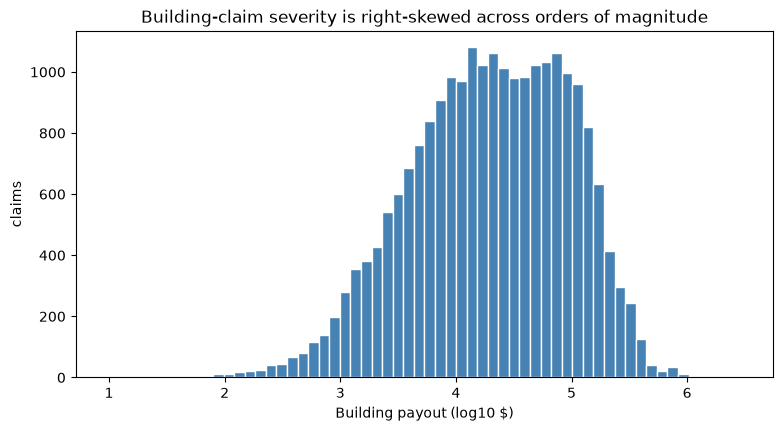

median $21,080   mean $52,765   max $2,946,987


In [116]:
# EDA
# payout distribution is right-skewed -> log-link
pos = model_df["amountPaidOnBuildingClaim"]
plt.hist(np.log10(pos), bins=60, color="steelblue", edgecolor="white")
plt.xlabel("Building payout (log10 $)")
plt.ylabel("claims")
plt.title("Building-claim severity is right-skewed across orders of magnitude")
plt.show()
print(f"median ${pos.median():,.0f}   mean ${pos.mean():,.0f}   max ${pos.max():,.0f}")

# NOTE: is this not just a replication of the figure above?  
# Or now it's with inflation taken into account?
# Could this be made more powerful by comparing the two histograms 
# (one with and one without inflation on the same axes?)

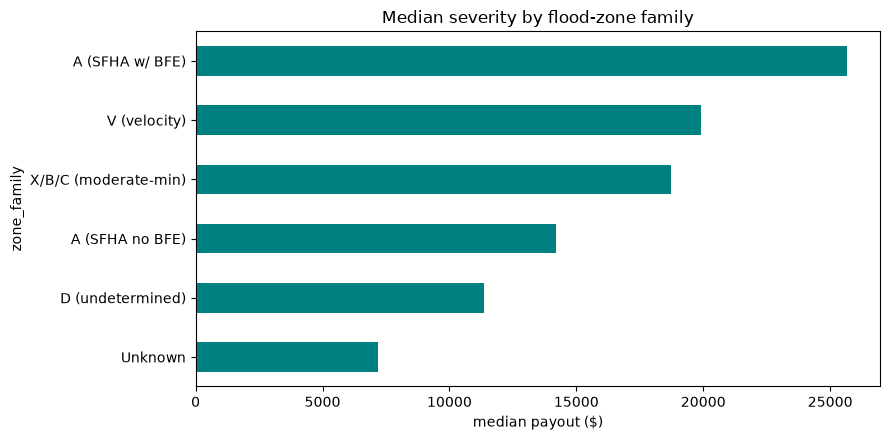

In [117]:
# median severity by flood-zone family
# the legacy zone scheme captures *some* signal (our baseline)
order = (
    model_df.groupby("zone_family")["amountPaidOnBuildingClaim"].median().sort_values()
)
order.plot(kind="barh", color="teal")
plt.xlabel("median payout ($)")
plt.title("Median severity by flood-zone family")
plt.tight_layout()
plt.show()

# Notes:
# put FEMA's zone codes (A01–A30, etc.) into six buckets:
# V (velocity) - any zone starting with V.
#   Coastal high-hazard areas exposed to wave action (most dangerous)
# A (SFHA w/ BFE)
#   zones starting with A that have a specific number (A01–A30, AE, etc.)
#   Special Flood Hazard Area with a Base Flood Elevation on record
# A (SFHA no BFE)
#   bare "A" zone.
#   Special Flood Hazard Area without an established Base Flood Elevation.
# X/B/C (moderate-min)
#   zones starting with X, B, or C.
#   Moderate-to-minimal risk, outside the 100-year floodplain.
# D (undetermined)
#   zone D. Risk exists but hasn't been assessed.
# Unknown
#   blank, missing, or anything that doesn't match the above.

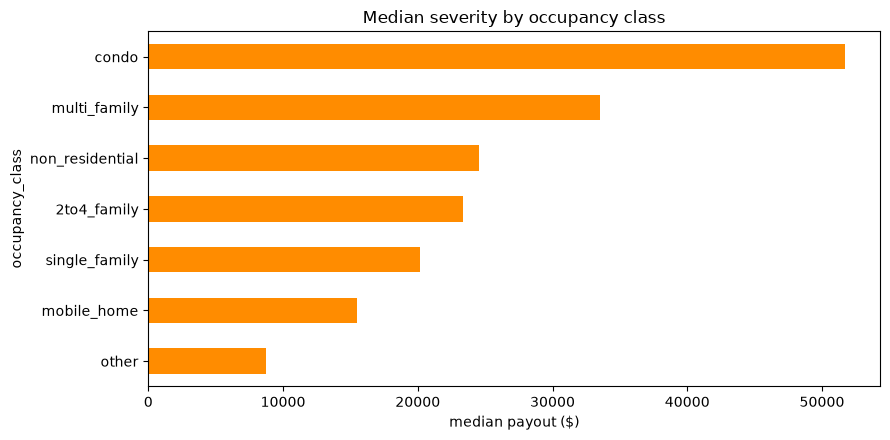

In [118]:
# occupancy class
model_df.groupby("occupancy_class")[
    "amountPaidOnBuildingClaim"
].median().sort_values().plot(kind="barh", color="darkorange")
plt.xlabel("median payout ($)")
plt.title("Median severity by occupancy class")
plt.tight_layout()
plt.show()

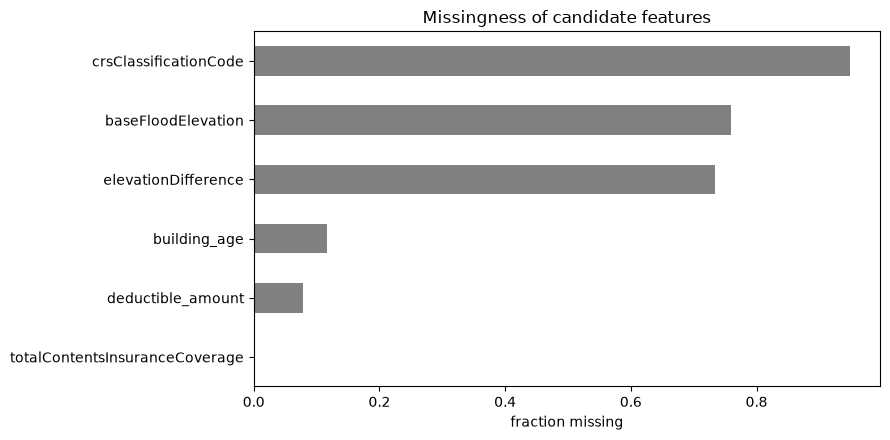

In [119]:
# how much is missing
# elevation fields mostly absent
miss = (
    model_df[
        [
            "elevationDifference",
            "baseFloodElevation",
            "building_age",
            "deductible_amount",
            "crsClassificationCode",
            "totalContentsInsuranceCoverage",
        ]
    ]
    .isna()
    .mean()
    .sort_values()
)
miss.plot(kind="barh", color="grey")
plt.xlabel("fraction missing")
plt.title("Missingness of candidate features")
plt.tight_layout()
plt.show()

## 7. Features and the leakage boundary

In [120]:
# leakage protection
# underwriting-time features only (present at underwriting)
# exclude everything post-flood to avoid leakage
NUMERIC = [
    "totalBuildingInsuranceCoverage",
    "totalContentsInsuranceCoverage",
    "deductible_amount",
    "building_age",
    "crsClassificationCode",
    "elevationDifference",
]
CATEG = [
    "zone_family",
    "occupancy_class",
    "state",
    "floors_cat",
    "basement_cat",
    "postFIRMConstructionIndicator_i",
    "elevatedBuildingIndicator_i",
    "primaryResidenceIndicator_i",
]
TARGET = "amountPaidOnBuildingClaim"

X = model_df[NUMERIC + CATEG].copy()
y = model_df[TARGET].astype(float).values

# excluded post-flood fields (using these would be leakage)
LEAKY = [
    "waterDepth",
    "floodWaterDuration",
    "causeOfDamage",
    "buildingDamageAmount",
    "netBuildingPaymentAmount",
    "floodEvent",
    "amountPaidOnContentsClaim",
]
print("features used   :", len(NUMERIC), "numeric +", len(CATEG), "categorical")
print("excluded (leaky):", ", ".join(LEAKY))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"\ntrain: {X_train.shape}   test: {X_test.shape}")

features used   : 6 numeric + 8 categorical
excluded (leaky): waterDepth, floodWaterDuration, causeOfDamage, buildingDamageAmount, netBuildingPaymentAmount, floodEvent, amountPaidOnContentsClaim

train: (17908, 14)   test: (4477, 14)


## 8. Preprocessing pipeline

In [121]:
# pipeline
preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
                    ("scale", StandardScaler()),
                ]
            ),
            NUMERIC,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),
            CATEG,
        ),
    ]
)
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 9. Models and a baseline to beat

| Model                                    | Family            |
| ---------------------------------------- | ----------------- |
| **Baseline - mean payout by flood zone** | trivial heuristic |
| **GLM (Gamma, log-link)**                | linear / GLM      |
| **GBM (gradient boosting, gamma loss)**  | tree ensemble     |


In [122]:
# helpers
def rmse(a, b):
    return mean_squared_error(a, b) ** 0.5


def score_row(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE ($)": mean_absolute_error(y_true, y_pred),
        "RMSE ($)": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


# two real models (the baseline is computed directly in the next cell)
# Gamma GLM
glm = Pipeline(
    [
        ("prep", preprocess),
        ("glm", TweedieRegressor(power=2, link="log", alpha=3, max_iter=5000)),
    ]
)
gbm = Pipeline(
    [
        ("prep", preprocess),
        (
            "gbm",
            HistGradientBoostingRegressor(
                loss="gamma",
                learning_rate=0.05,
                max_iter=400,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
print("models defined")

models defined


## 10. Evaluation — random 80/20 split

In [ ]:
# BE note:
# > local runtime on full data:     ~ 1m 10.4s
# > local runtime on sample data:   ~ 0m 02.3s
results = []

# Baseline
# mean payout by rated flood zone (legacy scheme), using TRAIN only (no leakage)
zone_mean = pd.Series(y_train, index=X_train["zone_family"]).groupby(level=0).mean()
baseline_pred = X_test["zone_family"].map(zone_mean).fillna(y_train.mean()).values
results.append(score_row("Baseline (zone mean)", y_test, baseline_pred))

# GLM
glm.fit(X_train, y_train)
results.append(score_row("GLM (Gamma, log-link)", y_test, glm.predict(X_test)))
# GBM
gbm.fit(X_train, y_train)
results.append(score_row("GBM (gamma loss)", y_test, gbm.predict(X_test)))

results_df = pd.DataFrame(results).set_index("Model")
print(results_df.round(2).to_string())

                        MAE ($)  RMSE ($)    R2
Model                                          
Baseline (zone mean)   51572.19  87581.43  0.02
GLM (Gamma, log-link)  50515.68  89056.32 -0.01
GBM (gamma loss)       38700.83  73202.02  0.32


In [ ]:
# BE note:
# > local runtime on full data:     ~ 4m 41.7s
# > local runtime on sample data:   ~ 0m 06.9s

# 5-fold cross-validated Mean Absolute Error
# > !not using test for tuning
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, est in [("GLM", glm), ("GBM", gbm)]:
    s = -cross_val_score(
        est, X_train, y_train, cv=cv, scoring="neg_mean_absolute_error"
    )
    print(f"CV MAE  {name}:  ${s.mean():,.0f}  ± ${s.std():,.0f}")

CV MAE  GLM:  $49,449  ± $1,349
CV MAE  GBM:  $37,818  ± $866


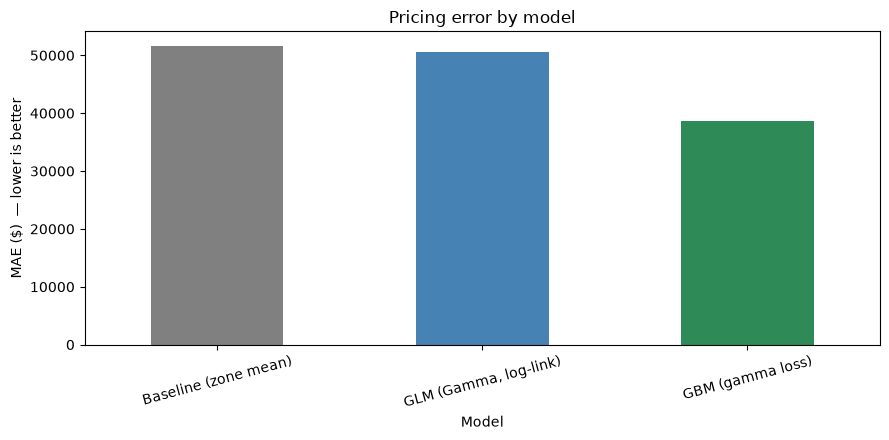

The GBM cuts average pricing error by 25% versus the legacy zone scheme.


,MAE ($),RMSE ($),R2
Model,,,
Baseline (zone mean),51572.190641,87581.431289,0.020651
"GLM (Gamma, log-link)",50515.684253,89056.315512,-0.012611
GBM (gamma loss),38700.834711,73202.022360,0.315837


In [125]:
# MAE by model (lower is better)
results_df["MAE ($)"].plot(kind="bar", color=["grey", "steelblue", "seagreen"])
plt.ylabel("MAE ($)  — lower is better")
plt.title("Pricing error by model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

b = results_df.loc["Baseline (zone mean)", "MAE ($)"]
g = results_df.loc["GBM (gamma loss)", "MAE ($)"]
print(
    f"The GBM cuts average pricing error by {(b-g)/b:.0%} versus the legacy zone scheme."
)

results_df

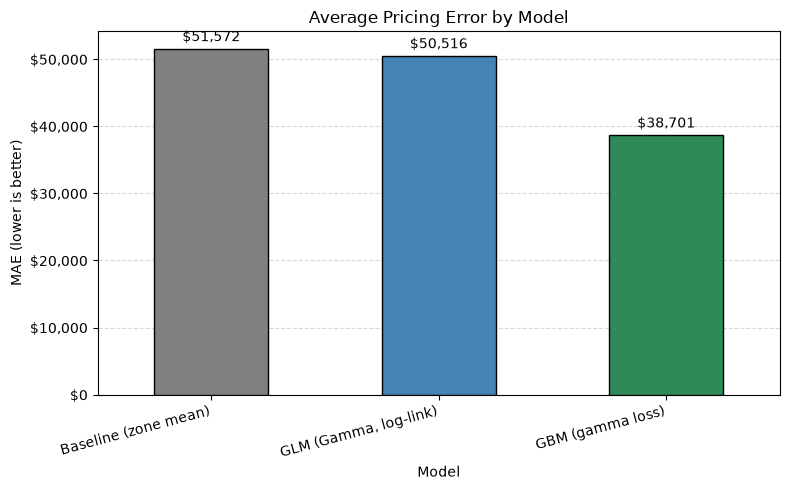


--- Model Impact ---
The GBM reduces average pricing error by 25.0% versus the legacy zone scheme
In absolute terms this is an improvement of $12,871 per claim on average


,MAE ($),RMSE ($),R2
Model,,,
Baseline (zone mean),51572.190641,87581.431289,0.020651
"GLM (Gamma, log-link)",50515.684253,89056.315512,-0.012611
GBM (gamma loss),38700.834711,73202.022360,0.315837


In [126]:
import matplotlib.ticker as ticker

ax = results_df["MAE ($)"].plot(
    kind="bar",
    color=["grey", "steelblue", "seagreen"],
    figsize=(8, 5), 
    edgecolor="black", 
    zorder=3, 
)

# top of bar labels
ax.bar_label(ax.containers[0], fmt="${:,.0f}", padding=3)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))

plt.ylabel("MAE (lower is better)")
plt.title("Average Pricing Error by Model")
plt.xticks(rotation=15, ha="right")  
plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
plt.tight_layout()
plt.show()

baseline_mae = results_df.loc["Baseline (zone mean)", "MAE ($)"]
gbm_mae = results_df.loc["GBM (gamma loss)", "MAE ($)"]

improvement_pct = (baseline_mae - gbm_mae) / baseline_mae
improvement_abs = baseline_mae - gbm_mae

print("\n--- Model Impact ---")
print(
    f"The GBM reduces average pricing error by {improvement_pct:.1%} versus the legacy zone scheme"
)
print(
    f"In absolute terms this is an improvement of ${improvement_abs:,.0f} per claim on average"
)
results_df

## 11. Tuning

In [ ]:
# tuning the models — cross-validated, cached
# BE note:
# > local runtime on full data:     ~ TBC
# > local runtime on sample data:   ~ 1m 48.2s (~1.4s to load from cache)
# The search is the expensive step (hours on the full data), so the chosen
# hyperparameters are persisted to models/tuned_params.json and reruns just
# load them and fit each model once. The cache is keyed by dataset mode, so
# parameters tuned on the SAMPLE are never silently reused for the FULL run
# (and vice versa). Set FORCE_RETUNE = True to repeat the search.
from sklearn.base import clone

TUNED_PARAMS = Path("models/tuned_params.json")
FORCE_RETUNE = False
mode_key = "sample" if USE_SAMPLE else "full"

cache = json.loads(TUNED_PARAMS.read_text()) if TUNED_PARAMS.exists() else {}
params = {} if FORCE_RETUNE else cache.get(mode_key, {})

if params:
    print(f"loaded cached tuned params [{mode_key}] from {TUNED_PARAMS}")
    print(json.dumps(params, indent=2))
    glm_best = clone(glm).set_params(**params["glm"]).fit(X_train, y_train)
    gbm_best = clone(gbm).set_params(**params["gbm"]).fit(X_train, y_train)
else:
    # GLM: cross-validate the regularisation strength
    glm_search = GridSearchCV(
        glm,
        {"glm__alpha": [1, 3, 10, 30, 100]},
        scoring="neg_mean_absolute_error",
        cv=cv,
    )
    glm_search.fit(X_train, y_train)
    print("GLM best alpha:", glm_search.best_params_["glm__alpha"])

    # GBM: small randomised search
    gbm_search = RandomizedSearchCV(
        gbm,
        {
            "gbm__learning_rate": [0.03, 0.05, 0.1],
            "gbm__max_leaf_nodes": [15, 31, 63],
            "gbm__max_iter": [300, 500],
            "gbm__l2_regularization": [0.0, 1.0, 10.0],
            "gbm__min_samples_leaf": [20, 50, 100],
        },
        n_iter=12,
        scoring="neg_mean_absolute_error",
        cv=cv,
        random_state=RANDOM_STATE,
    )
    gbm_search.fit(X_train, y_train)
    print(
        "GBM best params:",
        {k.replace("gbm__", ""): v for k, v in gbm_search.best_params_.items()},
    )

    glm_best = glm_search.best_estimator_
    gbm_best = gbm_search.best_estimator_

    # persist as human-readable JSON 
    # According to genAI this is immune to library-version drift and also 
    # doubles as an appendix artefact
    cache[mode_key] = {"glm": glm_search.best_params_, "gbm": gbm_search.best_params_}
    TUNED_PARAMS.parent.mkdir(parents=True, exist_ok=True)
    TUNED_PARAMS.write_text(json.dumps(cache, indent=2))
    print(f"saved tuned params [{mode_key}] -> {TUNED_PARAMS}")

# refresh the scoreboard with the tuned models
tuned = [
    score_row("Baseline (zone mean)", y_test, baseline_pred),
    score_row("GLM (tuned)", y_test, glm_best.predict(X_test)),
    score_row("GBM (tuned)", y_test, gbm_best.predict(X_test)),
]
tuned_df = pd.DataFrame(tuned).set_index("Model")
print("\n", tuned_df.round(3).to_string())
best_model = gbm_best  # used for interpretation and pricing below

loaded cached tuned params [sample] from models/tuned_params.json
{
  "glm": {
    "glm__alpha": 3
  },
  "gbm": {
    "gbm__min_samples_leaf": 20,
    "gbm__max_leaf_nodes": 63,
    "gbm__max_iter": 500,
    "gbm__learning_rate": 0.1,
    "gbm__l2_regularization": 0.0
  }
}

                         MAE ($)   RMSE ($)     R2
Model                                            
Baseline (zone mean)  51572.191  87581.431  0.021
GLM (tuned)           50515.684  89056.316 -0.013
GBM (tuned)           38180.179  73557.483  0.309


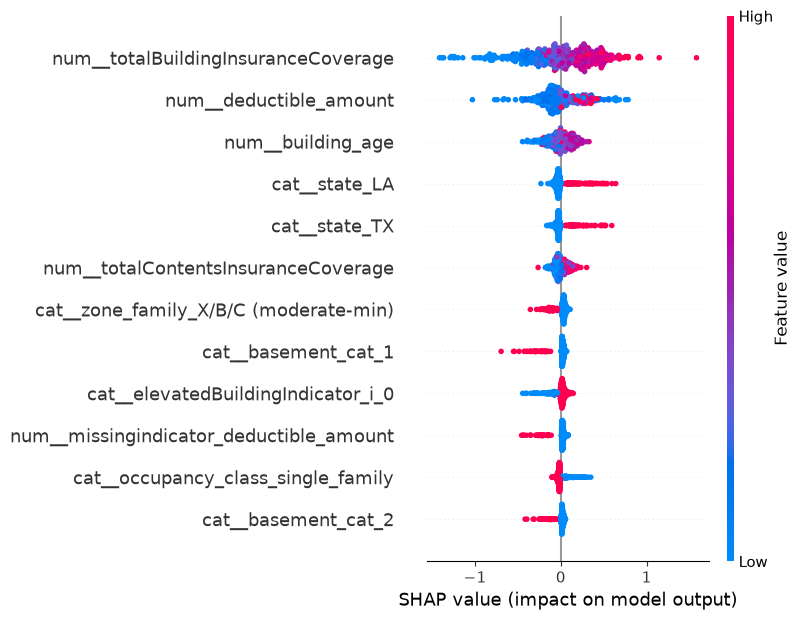

In [130]:
# sample of the training rows for speed.
Xt = best_model.named_steps["prep"].transform(X_train)
feature_names = best_model.named_steps["prep"].get_feature_names_out()
explainer = shap.TreeExplainer(best_model.named_steps["gbm"])
shap_values = explainer.shap_values(Xt[:500])
shap.summary_plot(
    shap_values, Xt[:500], feature_names=feature_names, show=True, max_display=12
)

In [131]:
# Get importance ranking
# mean absolute SHAP value
importance = (
    pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
    .sort_values(ascending=False)
    .head(10)
)
print("Top drivers (mean |SHAP|):")
print(importance.to_string())

Top drivers (mean |SHAP|):
num__totalBuildingInsuranceCoverage        0.319885
num__deductible_amount                     0.170893
num__building_age                          0.102499
cat__state_LA                              0.071109
cat__state_TX                              0.063019
num__totalContentsInsuranceCoverage        0.057758
cat__zone_family_X/B/C (moderate-min)      0.053658
cat__basement_cat_1                        0.047281
cat__elevatedBuildingIndicator_i_0         0.045315
num__missingindicator_deductible_amount    0.041188


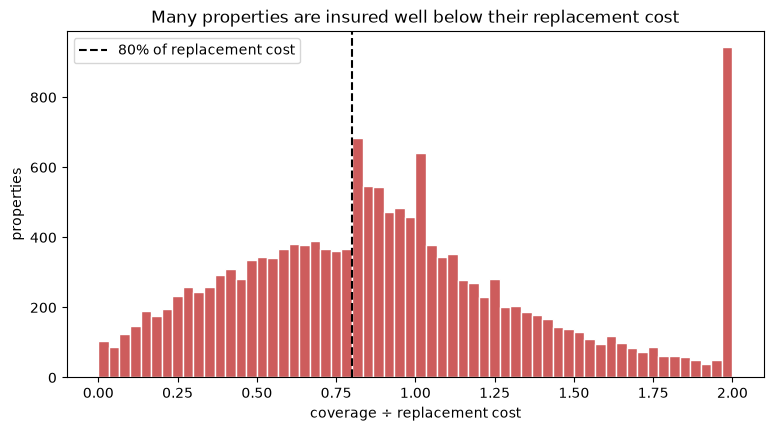

properties assessed       : 15,778
median coverage/replacement: 0.88
under-insured (<80%)       : 41%
severely under-insured(<50%): 20%


In [133]:
# behaviour explore
# coverage vs replacement cost - just where both are present
rc = pd.to_numeric(model_df["buildingReplacementCost"], errors="coerce")
cov = model_df["totalBuildingInsuranceCoverage"]
ok = rc.notna() & cov.notna() & (rc > 0)
ratio = (cov[ok] / rc[ok]).clip(upper=2)  # coverage as a fraction of replacement cost

plt.hist(ratio, bins=60, color="indianred", edgecolor="white")
plt.axvline(0.8, color="black", ls="--", label="80% of replacement cost")
plt.xlabel("coverage ÷ replacement cost")
plt.ylabel("properties")
plt.legend()
plt.title("Many properties are insured well below their replacement cost")
plt.show()

print(f"properties assessed       : {int(ok.sum()):,}")
print(f"median coverage/replacement: {ratio.median():.2f}")
print(f"under-insured (<80%)       : {(ratio < 0.8).mean():.0%}")
print(f"severely under-insured(<50%): {(ratio < 0.5).mean():.0%}")

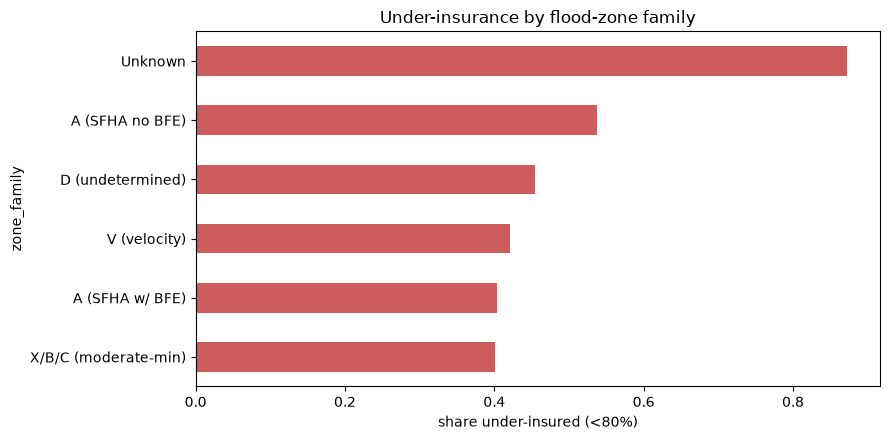

In [134]:
# Which segments are most under-insured? (share below 80% of replacement cost, by flood zone)
seg = (ratio < 0.8).groupby(model_df.loc[ok, "zone_family"]).mean().sort_values()
seg.plot(kind="barh", color="indianred")
plt.xlabel("share under-insured (<80%)")
plt.title("Under-insurance by flood-zone family")
plt.tight_layout()
plt.show()

In [135]:
# Model-implied severity for every modelled property, vs the flat zone-average it is priced at today
model_df = model_df.copy()
model_df["pred_severity"] = best_model.predict(X)

# Focus on the largest zone and show the within-zone spread the flat rate ignores
zone = model_df["zone_family"].value_counts().idxmax()
sub = model_df[model_df["zone_family"] == zone]
zone_flat = sub[
    "amountPaidOnBuildingClaim"
].mean()  # what flat zone pricing charges everyone here
deciles = sub["pred_severity"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(0)

print(f"Largest zone: {zone}  (flat zone severity = ${zone_flat:,.0f})")
print("Model-implied severity within this zone (deciles):")
print(deciles.to_string())
rel = deciles / zone_flat
print("\nImplied relativity to the flat zone rate:")
print(rel.round(2).to_string())
print(
    f"\n=> Within a single zone, the model says the top-decile risk should pay about "
    f"{rel.loc[0.9]:.1f}x what the bottom-decile risk pays — differentiation the flat rate misses."
)

Largest zone: A (SFHA w/ BFE)  (flat zone severity = $59,812)
Model-implied severity within this zone (deciles):
0.10     13495.0
0.25     21357.0
0.50     36520.0
0.75     72535.0
0.90    114033.0

Implied relativity to the flat zone rate:
0.10    0.23
0.25    0.36
0.50    0.61
0.75    1.21
0.90    1.91

=> Within a single zone, the model says the top-decile risk should pay about 1.9x what the bottom-decile risk pays — differentiation the flat rate misses.
